In [1]:
import numpy as np
import h5py
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import cv2
from datetime import datetime
import matplotlib.animation as animation
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from astropy import units as u
from astropy.io import fits
from sunpy.net import Fido, attrs as a
import sunpy.visualization.colormaps as cm 
from astropy import uncertainty as unc
from astropy.visualization import quantity_support
from astropy.visualization import simple_norm, ContrastBiasStretch,ManualInterval,LinearStretch,MinMaxInterval,ImageNormalize, SqrtStretch,LogStretch,PowerDistStretch,PowerStretch,SinhStretch,SquaredStretch,AsinhStretch,PercentileInterval
%matplotlib widget

sdoaia131 = matplotlib.colormaps['sdoaia131']


In [2]:
with h5py.File('final_curve_s1','r') as file1:
    x_range1 = file1['x_range1'][:]
    sampled_x1 = file1['sampled_x1'][:]
    true_poly1 = file1['true_poly1'][:]
    start_velocities1 = file1['start_velocities1'][:]
    end_velocities1 = file1['end_velocities1'][:]
    measured_derivatives1 = file1['measured_derivatives1'][:]
    true_derivative1 = file1['true_derivative1'][:]
    curves1 = file1['curves1'][:]
    sheet_cube = file1['sheet_cube'][:]
    x_lims = file1['x_lims'][:]
    x_lims2 = file1['x_lims2'][:]
    yticks = file1['yticks'][:]
    vi1 = file1['vi1'][()]
    vf1 = file1['vf1'][()]
    vi_u1 = file1['vi_u1'][()]
    vf_u1 = file1['vf_u1'][()]

with h5py.File('final_curve_s2','r') as file2:
    x_range2 = file2['x_range2'][:]
    sampled_x2 = file2['sampled_x2'][:]
    true_poly2 = file2['true_poly2'][:]
    start_velocities2 = file2['start_velocities2'][:]
    end_velocities2 = file2['end_velocities2'][:]
    measured_derivatives2 = file2['measured_derivatives2'][:]
    true_derivative2 = file2['true_derivative2'][:]
    curves2 = file2['curves2'][:]
    vi2 = file2['vi2'][()]
    vf2 = file2['vf2'][()]
    vi_u2 = file2['vi_u2'][()]
    vf_u2 = file2['vf_u2'][()]

with h5py.File('final_curve_s3','r') as file3:
    x_range3 = file3['x_range3'][:]
    sampled_x3 = file3['sampled_x3'][:]
    true_poly3 = file3['true_poly3'][:]
    start_velocities3 = file3['start_velocities3'][:]
    end_velocities3 = file3['end_velocities3'][:]
    measured_derivatives3 = file3['measured_derivatives3'][:]
    true_derivative3 = file3['true_derivative3'][:]
    curves3 = file3['curves3'][:]
    vi3 = file3['vi3'][()]
    vf3 = file3['vf3'][()]
    vi_u3 = file3['vi_u3'][()]
    vf_u3 = file3['vf_u3'][()]

with h5py.File('final_curve_s4','r') as file4:
    x_range4 = file4['x_range4'][:]
    sampled_x4 = file4['sampled_x4'][:]
    true_poly4 = file4['true_poly4'][:]
    start_velocities4 = file4['start_velocities4'][:]
    end_velocities4 = file4['end_velocities4'][:]
    measured_derivatives4 = file4['measured_derivatives4'][:]
    true_derivative4 = file4['true_derivative4'][:]
    curves4 = file4['curves4'][:]
    vi4 = file4['vi4'][()]
    vf4 = file4['vf4'][()]
    vi_u4 = file4['vi_u4'][()]
    vf_u4 = file4['vf_u4'][()]

with h5py.File('final_curve_s5','r') as file5:
    x_range5 = file5['x_range5'][:]
    sampled_x5 = file5['sampled_x5'][:]
    true_poly5 = file5['true_poly5'][:]
    start_velocities5 = file5['start_velocities5'][:]
    end_velocities5 = file5['end_velocities5'][:]
    measured_derivatives5 = file5['measured_derivatives5'][:]
    true_derivative5 = file5['true_derivative5'][:]
    curves5 = file5['curves5'][:]
    vi5 = file5['vi5'][()]
    vf5 = file5['vf5'][()]
    vi_u5 = file5['vi_u5'][()]
    vf_u5 = file5['vf_u5'][()]

with h5py.File('final_curve_s6','r') as file6:
    x_range6 = file6['x_range6'][:]
    sampled_x6 = file6['sampled_x6'][:]
    true_poly6 = file6['true_poly6'][:]
    start_velocities6 = file6['start_velocities6'][:]
    end_velocities6 = file6['end_velocities6'][:]
    measured_derivatives6 = file6['measured_derivatives6'][:]
    true_derivative6 = file6['true_derivative6'][:]
    curves6 = file6['curves6'][:]
    vi6 = file6['vi6'][()]
    vf6 = file6['vf6'][()]
    vi_u6 = file6['vi_u6'][()]
    vf_u6 = file6['vf_u6'][()]

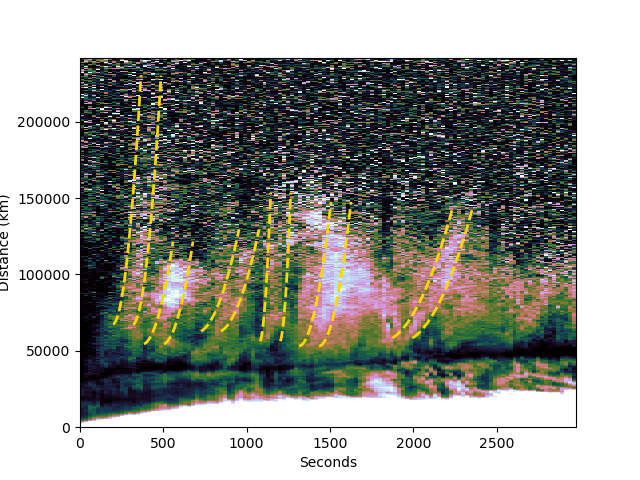

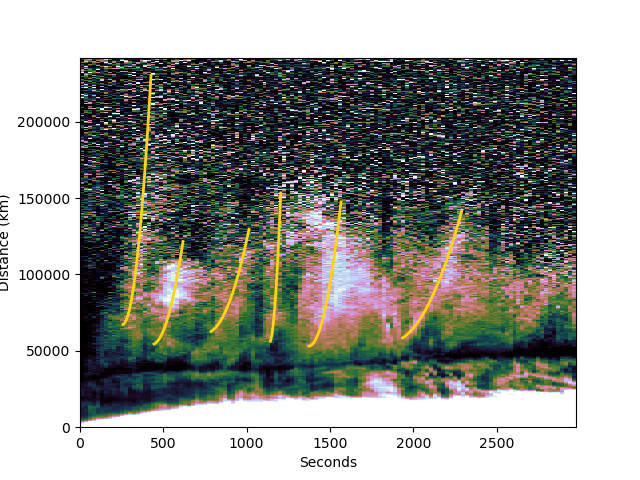

In [3]:
fig1, ax1 = plt.subplots()
plt.imshow(sheet_cube**2, vmin = 0, vmax = 0.4**2.15, cmap = 'cubehelix', extent=[x_lims2[0], x_lims2[-1], 0,yticks[-1]],interpolation='None')
#for curve in curves2:
    #ax5.plot(sampled_x2, np.polyval(curve, sampled_x2))
ax1.plot(sampled_x1, np.polyval(true_poly1, sampled_x1), color='gold', linewidth=2)
ax1.plot(sampled_x2, np.polyval(true_poly2, sampled_x2), color='gold', linewidth=2)
ax1.plot(sampled_x3, np.polyval(true_poly3, sampled_x3), color='gold', linewidth=2)
ax1.plot(sampled_x4, np.polyval(true_poly4, sampled_x4), color='gold', linewidth=2)
ax1.plot(sampled_x5, np.polyval(true_poly5, sampled_x5), color='gold', linewidth=2)
ax1.plot(sampled_x6, np.polyval(true_poly6, sampled_x6), color='gold', linewidth=2)



ax1.set_aspect('auto')
ax1.set_xlabel('Seconds')
ax1.set_ylabel('Distance (km)')

fig2, ax2 = plt.subplots()
plt.imshow(sheet_cube**2, vmin = 0, vmax = 0.4**2.15, cmap = 'cubehelix', extent=[x_lims2[0], x_lims2[-1], 0,yticks[-1]],interpolation='None')
#for curve in curves2:
    #ax5.plot(sampled_x2, np.polyval(curve, sampled_x2))
ax2.plot(sampled_x1-60, np.polyval(true_poly1, sampled_x1), color='gold',linestyle ='--', linewidth=2)
ax2.plot(sampled_x1+60, np.polyval(true_poly1, sampled_x1), color='gold',linestyle ='--', linewidth=2)
ax2.plot(sampled_x2-60, np.polyval(true_poly2, sampled_x2), color='gold',linestyle ='--', linewidth=2)
ax2.plot(sampled_x2+60, np.polyval(true_poly2, sampled_x2), color='gold',linestyle ='--', linewidth=2)
ax2.plot(sampled_x3-60, np.polyval(true_poly3, sampled_x3), color='gold',linestyle ='--', linewidth=2)
ax2.plot(sampled_x3+60, np.polyval(true_poly3, sampled_x3), color='gold',linestyle ='--', linewidth=2)
ax2.plot(sampled_x4-60, np.polyval(true_poly4, sampled_x4), color='gold',linestyle ='--', linewidth=2)
ax2.plot(sampled_x4+60, np.polyval(true_poly4, sampled_x4), color='gold',linestyle ='--', linewidth=2)
ax2.plot(sampled_x5-60, np.polyval(true_poly5, sampled_x5), color='gold',linestyle ='--', linewidth=2)
ax2.plot(sampled_x5+60, np.polyval(true_poly5, sampled_x5), color='gold',linestyle ='--', linewidth=2)
ax2.plot(sampled_x6-60, np.polyval(true_poly6, sampled_x6), color='gold',linestyle ='--', linewidth=2)
ax2.plot(sampled_x6+60, np.polyval(true_poly6, sampled_x6), color='gold',linestyle ='--', linewidth=2)

ax1.set_title('')
ax2.set_title('')
ax2.set_aspect('auto')
ax2.set_xlabel('Seconds')
ax2.set_ylabel('Distance (km)')

plt.show()


In [4]:
plt.close('all')

In [6]:
import numpy as np

In [5]:
fig1.savefig("Flows_Paths.pdf", bbox_inches='tight')
fig2.savefig("Flows_Outlines.pdf", bbox_inches='tight')

In [40]:
def polynomial_derivative(coefficients):
    return [i*coeff for i, coeff in zip(range(len(coefficients)-1, 0, -1), coefficients)]

def convert_times(seconds):
    numdate = (seconds/86400) + x_lims.min()
    date = mdates.num2date(numdate)
    return date.strftime("%H:%M:%S")

In [41]:
a_1 = polynomial_derivative(true_derivative1)
a_2 = polynomial_derivative(true_derivative2)
a_3 = polynomial_derivative(true_derivative3)
a_4 = polynomial_derivative(true_derivative4)
a_5 = polynomial_derivative(true_derivative5)
a_6 = polynomial_derivative(true_derivative6)

In [42]:
a_1f = np.polyval(a_1, x_range1[1])
a_2f = np.polyval(a_2, x_range2[1])
a_3f = np.polyval(a_3, x_range3[1])
a_4f = np.polyval(a_4, x_range4[1])
a_5f = np.polyval(a_5, x_range5[1])
a_6f = np.polyval(a_6, x_range6[1])

In [43]:
print(a_1f, a_2f, a_3f, a_4f, a_5f, a_6f)

11.099277065331826 3.9162755908975946 2.0219690143840863 40.89065677127955 5.025648465326023 0.9226276398737212


In [46]:
s1_start = convert_times(x_range1[0])
s1_end = convert_times(x_range1[1])
s2_start = convert_times(x_range2[0])
s2_end = convert_times(x_range2[1])
s3_start = convert_times(x_range3[0])
s3_end = convert_times(x_range3[1])
s4_start = convert_times(x_range4[0])
s4_end = convert_times(x_range4[1])
s5_start = convert_times(x_range5[0])
s5_end = convert_times(x_range5[1])
s6_start = convert_times(x_range6[0])
s6_end = convert_times(x_range6[1])

In [53]:
print(s1_start, s1_end)
print(s2_start, s2_end)
print(s3_start, s3_end)
print(s4_start, s4_end)
print(s5_start, s5_end)
print(s6_start, s6_end)

16:09:26 16:12:14
16:12:32 16:15:26
16:18:14 16:22:02
16:24:10 16:25:12
16:28:02 16:31:14
16:37:24 16:43:20


In [30]:
test_num = mdates.num2date(test_convert)

In [31]:
print(test_num)

2013-05-13 16:09:26.620000+00:00


In [32]:
date_format = mdates.DateFormatter('%H:%M:%S')

In [35]:
print(test_num.strftime("%H:%M:%S"))

16:09:26
